# Can we predict phenotype from microbiome profiles?

**Machine Learning  — Metagenomics Summer School**

This notebook is designed as a guided computational lab. You do **not** need to write Python from scratch. Your task is to run cells, inspect outputs, make decisions, and discuss whether the ML pipeline is scientifically defensible.

Main question:

> **Can we predict phenotype / disease status from microbiome profiles?**

But the real objective is more critical:

> **Can we trust the model, and why?**

The dataset used today (`microbiome_synthetic.csv`) is **synthetic**: samples, taxa abundances, health status, and a technical `batch` variable were generated so that the instructor knows the ground truth.

## How to use this notebook

Cells are organized into four types:

🟢 **RUN** — execute the cell without editing.
🔵 **CHOOSE** — change one option from a dropdown or parameter, then run.
🟡 **VOTE** — a markdown cell with a question. Discuss and commit to an answer as a group *before* running the next cell.
🔴 **DISCUSS** — answer conceptually after seeing a result; no coding required.
🔒 **INSTRUCTOR ONLY** — run this after the class discussion, not before.



In [75]:
#@title 🟢 RUN — Install optional packages
# SHAP is optional. If installation fails, the notebook will continue with permutation importance.
try:
    import shap  # noqa: F401
    print("SHAP already installed.")
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "shap"])
    print("SHAP installed.")

SHAP already installed.


In [76]:
#@title 🟢 RUN — Imports
import warnings
warnings.filterwarnings("ignore")

import os
from typing import Optional, Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import pdist, squareform

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GroupKFold,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Part 1 — Load and inspect the dataset

In [77]:
#@title 🔵 CHOOSE — Load the dataset
csv_path = "microbiome_synthetic.csv" #@param {type:"string"}
target_col = "health_status" #@param {type:"string"}
batch_col = "batch" #@param {type:"string"}

df = pd.read_csv(csv_path, index_col=0)

# Feature columns are ONLY the microbial taxa -- metadata (target, batch)
# must never silently leak in as a "feature".
feature_cols = [c for c in df.columns if c.startswith("Taxon_")]
metadata_cols = [c for c in [target_col, batch_col] if c in df.columns]

print("Dataset shape:", df.shape)
print("Number of taxa (features):", len(feature_cols))
print("Metadata columns:", metadata_cols)
display(df.head())

if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found. Available columns: {df.columns.tolist()[:10]}...")

Dataset shape: (150, 402)
Number of taxa (features): 400
Metadata columns: ['health_status', 'batch']


,Taxon_0001,Taxon_0002,Taxon_0003,Taxon_0004,Taxon_0005,Taxon_0006,Taxon_0007,Taxon_0008,Taxon_0009,Taxon_0010,...,Taxon_0393,Taxon_0394,Taxon_0395,Taxon_0396,Taxon_0397,Taxon_0398,Taxon_0399,Taxon_0400,health_status,batch
sample_id,,,,,,,,,,,,,,,,,,,,,
S001,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,Control,batch_3
S002,0,0,0,1,0,0,2,0,2,0,...,0,1,0,1,0,0,0,0,Control,batch_3
S003,0,0,1,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,Control,batch_1
S004,0,0,0,0,2,2,0,0,0,1,...,0,0,0,0,0,0,0,0,Case,batch_2
S005,1,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,Case,batch_3


🟡 **VOTE — before you run the next cell**

Look only at the shape you just printed above (samples × taxa).

Vote as a group: what fraction of this table do you expect to be **zero counts**?

A. Less than 20%
B. 20–50%
C. 50–80%
D. More than 80%

Now run the next cell and check who was closest.

In [78]:
#@title 🟢 RUN — Basic dataset summary
X_raw = df[feature_cols].copy()
y_raw = df[target_col].copy()
batch_raw = df[batch_col].copy() if batch_col in df.columns else None

print("Number of samples:", X_raw.shape[0])
print("Number of microbial features:", X_raw.shape[1])

print("\nClass distribution:")
display(y_raw.value_counts().to_frame("n"))

if batch_raw is not None:
    print("\nBatch distribution:")
    display(batch_raw.value_counts().to_frame("n"))
    print("\nhealth_status x batch (cross-tabulation):")
    display(pd.crosstab(y_raw, batch_raw))

zero_fraction = (X_raw.values == 0).mean()
sample_depth = X_raw.sum(axis=1)

print(f"\nOverall zero fraction: {zero_fraction:.3f}")
print(f"Median sequencing depth / total counts: {sample_depth.median():.2e}")
print(f"Min sequencing depth / total counts: {sample_depth.min():.2e}")
print(f"Max sequencing depth / total counts: {sample_depth.max():.2e}")

Number of samples: 150
Number of microbial features: 400

Class distribution:


,n
health_status,
Control,91
Case,59



Batch distribution:


,n
batch,
batch_3,63
batch_1,60
batch_2,27



health_status x batch (cross-tabulation):


batch,batch_1,batch_2,batch_3
health_status,,,
Case,14,10,35
Control,46,17,28



Overall zero fraction: 0.655
Median sequencing depth / total counts: 3.47e+04
Min sequencing depth / total counts: 1.29e+04
Max sequencing depth / total counts: 8.20e+04


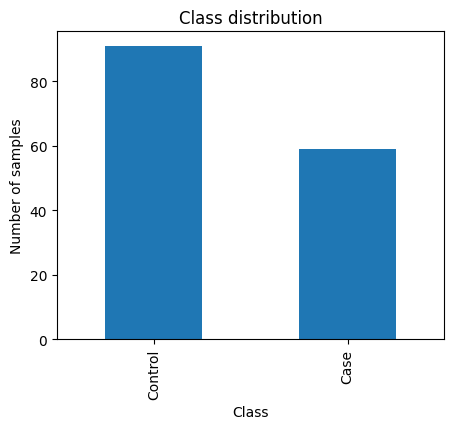

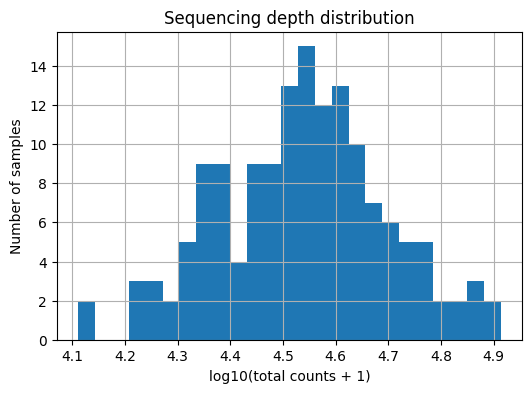

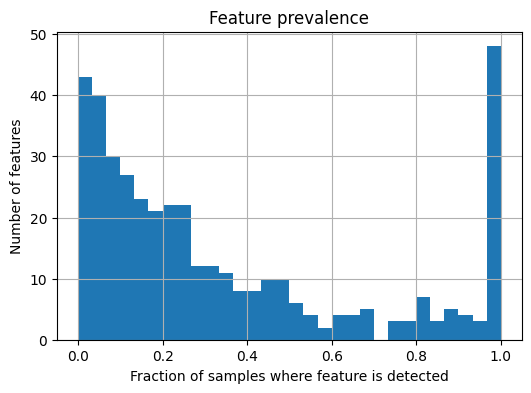

In [79]:
#@title 🟢 RUN — Visual inspection: class balance, sequencing depth, sparsity
fig, ax = plt.subplots(figsize=(5, 4))
y_raw.value_counts().plot(kind="bar", ax=ax)
ax.set_title("Class distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of samples")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
np.log10(sample_depth + 1).hist(bins=25, ax=ax)
ax.set_title("Sequencing depth distribution")
ax.set_xlabel("log10(total counts + 1)")
ax.set_ylabel("Number of samples")
plt.show()

feature_prevalence = (X_raw > 0).mean(axis=0)
fig, ax = plt.subplots(figsize=(6, 4))
feature_prevalence.hist(bins=30, ax=ax)
ax.set_title("Feature prevalence")
ax.set_xlabel("Fraction of samples where feature is detected")
ax.set_ylabel("Number of features")
plt.show()

🔴 **DISCUSS 1 — What worries you before modelling?**

Look at the outputs above, including the `health_status x batch` cross-tabulation.

Which risks are already visible?

A. High dimensionality: many more features than samples
B. Sparsity: many zeros
C. Class imbalance
D. Sequencing-depth variability
E. The `health_status x batch` table looks unbalanced -- batch could be a confounder
F. Nothing; we can train a model immediately

<details>
<summary>💡 Show discussion notes</summary>

In microbiome ML, most problems start before the algorithm -- and E is exactly the kind of thing to keep in your back pocket for later in this notebook.

</details>

# Part 2 — Representation choice

Before applying PCA or ML, we choose how to represent the microbiome table.

- `raw_counts`: original counts; easy but may encode sequencing depth.
- `relative_abundance`: each sample sums to 1; intuitive but compositional.
- `clr`: centered log-ratio transformation; CoDa-aware, requires zero handling.
- `presence_absence`: only detected/not detected; ignores abundance magnitude.

In [80]:
#@title 🟢 RUN — Helper functions for microbiome preprocessing
class MicrobiomePreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, representation="clr", min_prevalence=0.05, pseudocount=1.0):
        self.representation = representation
        self.min_prevalence = min_prevalence
        self.pseudocount = pseudocount

    def fit(self, X, y=None):
        X_arr = self._to_numpy(X)
        prevalence = (X_arr > 0).mean(axis=0)
        self.feature_mask_ = prevalence >= self.min_prevalence
        if self.feature_mask_.sum() == 0:
            raise ValueError("No features left after prevalence filtering. Lower min_prevalence.")
        return self

    def transform(self, X):
        X_arr = self._to_numpy(X)[:, self.feature_mask_].astype(float)

        if self.representation == "raw_counts":
            return X_arr

        if self.representation == "presence_absence":
            return (X_arr > 0).astype(float)

        if self.representation == "relative_abundance":
            row_sum = X_arr.sum(axis=1, keepdims=True)
            row_sum[row_sum == 0] = 1.0
            return X_arr / row_sum

        if self.representation == "clr":
            X_pc = X_arr + self.pseudocount
            row_sum = X_pc.sum(axis=1, keepdims=True)
            rel = X_pc / row_sum
            log_rel = np.log(rel)
            return log_rel - log_rel.mean(axis=1, keepdims=True)

        raise ValueError(f"Unknown representation: {self.representation}")

    @staticmethod
    def _to_numpy(X):
        if isinstance(X, (pd.DataFrame, pd.Series)):
            return X.values
        return np.asarray(X)


def get_transformed_matrix(X, representation, min_prevalence, pseudocount):
    pre = MicrobiomePreprocessor(representation, min_prevalence, pseudocount)
    Xt = pre.fit_transform(X)
    selected_features = X.columns[pre.feature_mask_].to_numpy()
    return Xt, selected_features


def encode_target(y, positive_label=None):
    labels = sorted(y.astype(str).unique())
    if positive_label is not None and positive_label in labels and len(labels) == 2:
        y_enc = (y.astype(str) == positive_label).astype(int).values
        class_names = [f"not {positive_label}", positive_label]
        return y_enc, class_names
    le = LabelEncoder()
    y_enc = le.fit_transform(y.astype(str))
    return y_enc, list(le.classes_)


def plot_pca(Xt, y, title):
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    coords = pca.fit_transform(Xt)
    fig, ax = plt.subplots(figsize=(6, 5))
    for label in sorted(y.astype(str).unique()):
        mask = y.astype(str).values == label
        ax.scatter(coords[mask, 0], coords[mask, 1], label=str(label), alpha=0.8)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_title(title)
    ax.legend(title="Group")
    plt.show()


def make_model(model_name, representation, min_prevalence, pseudocount):
    pre = MicrobiomePreprocessor(representation, min_prevalence, pseudocount)

    if model_name == "logistic_regression":
        clf = LogisticRegression(max_iter=3000, class_weight="balanced", solver="liblinear", random_state=RANDOM_STATE)
        return Pipeline([("preprocess", pre), ("scale", StandardScaler()), ("model", clf)])

    if model_name == "random_forest":
        clf = RandomForestClassifier(n_estimators=500, max_features="sqrt", min_samples_leaf=2,
                                     class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1)
        return Pipeline([("preprocess", pre), ("model", clf)])

    raise ValueError(f"Unknown model: {model_name}")


def evaluate_holdout(model, X, y, test_size=0.25):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    score = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else pred

    metrics = {
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, score) if len(np.unique(y_test)) == 2 else np.nan,
    }

    print(pd.Series(metrics).round(3))
    print("Classification report:")
    print(classification_report(y_test, pred, zero_division=0))

    ConfusionMatrixDisplay.from_predictions(y_test, pred)
    plt.title("Confusion matrix")
    plt.show()

    if len(np.unique(y_test)) == 2:
        RocCurveDisplay.from_predictions(y_test, score)
        plt.title("ROC curve")
        plt.show()
        PrecisionRecallDisplay.from_predictions(y_test, score)
        plt.title("Precision-recall curve")
        plt.show()

    return model, (X_train, X_test, y_train, y_test)

def evaluate_cv(model, X, y, cv_strategy="stratified_cv", groups=None):
    scoring = {"accuracy": "accuracy", "balanced_accuracy": "balanced_accuracy", "f1": "f1", "roc_auc": "roc_auc"}

    if cv_strategy == "stratified_cv":
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        out = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    elif cv_strategy == "grouped_cv":
        if groups is None:
            raise ValueError("Grouped CV requires a group variable.")
        cv = GroupKFold(n_splits=min(5, len(np.unique(groups))))
        out = cross_validate(model, X, y, cv=cv, scoring=scoring, groups=groups, n_jobs=-1)
    else:
        raise ValueError("cv_strategy must be 'stratified_cv' or 'grouped_cv'.")

    rows = []
    for k in scoring:
        vals = out[f"test_{k}"]
        rows.append({"metric": k, "mean": np.nanmean(vals), "std": np.nanstd(vals)})
    result = pd.DataFrame(rows)
    display(result.round(3))
    return result

🟡 **VOTE — before you run the next cell**

We are about to run PCA on CLR-transformed data, and plot the same two principal components twice: once colored by `health_status`, once by `batch`.

Vote: which grouping do you expect to separate more cleanly?

A. `health_status` separates more cleanly
B. `batch` separates more cleanly
C. Neither separates cleanly
D. Both separate equally well

Now run the next cell.

Representation: clr
Selected features after prevalence filtering: 332
Transformed matrix shape: (150, 332)
Mean: -0.0 Std: 2.0471


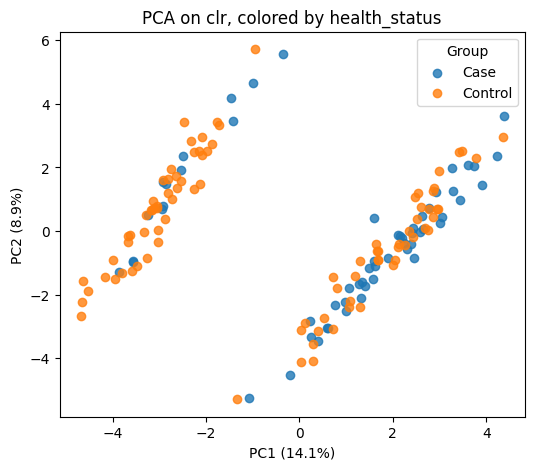

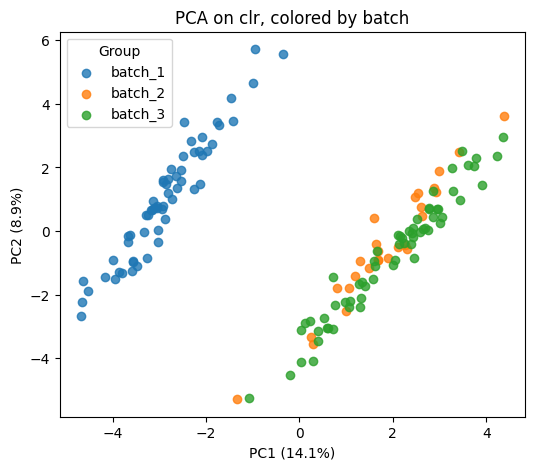

In [81]:
#@title 🔵 CHOOSE — Representation for exploratory analysis
representation = "clr" #@param ["raw_counts", "relative_abundance", "clr", "presence_absence"]
min_prevalence = 0.05 #@param {type:"number"}
pseudocount = 1.0 #@param {type:"number"}

Xt, selected_features = get_transformed_matrix(X_raw, representation, min_prevalence, pseudocount)

print("Representation:", representation)
print("Selected features after prevalence filtering:", len(selected_features))
print("Transformed matrix shape:", Xt.shape)
print("Mean:", np.mean(Xt).round(4), "Std:", np.std(Xt).round(4))

plot_pca(Xt, y_raw, title=f"PCA on {representation}, colored by health_status")
if batch_raw is not None:
    plot_pca(Xt, batch_raw, title=f"PCA on {representation}, colored by batch")

🔴 **DISCUSS 2 — Which representation is defensible?**

Suppose PCA shows separation between groups.

Can we immediately conclude there is a biological disease signal?

A. Yes, PCA separation proves biological signal.
B. No, separation could reflect batch, sequencing depth, or other confounders.
C. PCA is exploratory; it suggests hypotheses but does not validate a classifier.
D. We need proper validation before making predictive claims.

<details>
<summary>💡 Show answer</summary>

B, C, D.

</details>

# Part 2b — Reducing dimensionality: prevalence filtering

400 taxa is a lot for 150 samples. Before any exploratory or supervised step, we drop taxa that are essentially absent from the dataset -- present in only a handful of samples, they cannot support a generalizable pattern, supervised or not.

This filter uses **only the abundance table -- never the label**. That distinction matters: an unsupervised filter like this one is safe to apply before splitting into train/test, because it cannot leak information about `health_status`. A filter that looks at the label (like the one we will deliberately misuse in Part 6) is not safe. Keep this contrast in mind for later.

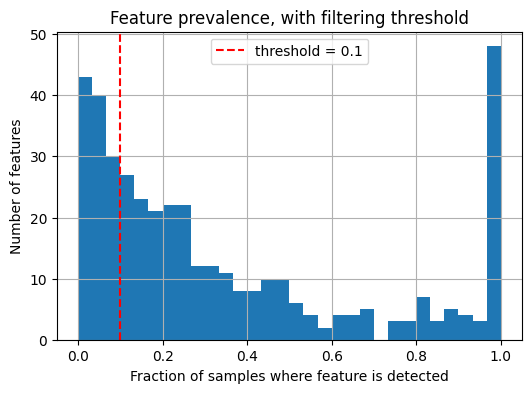

Features before filtering: 400
Features after filtering (prevalence >= 0.1): 287
Features removed: 113

Transformed matrix used from here on: (150, 287)


In [82]:
#@title 🔵 CHOOSE — Prevalence filter (unsupervised, label-free feature selection)
min_prevalence_filter = 0.10 #@param {type:"number"}

prevalence_all = (X_raw > 0).mean(axis=0)
kept_mask = prevalence_all >= min_prevalence_filter
n_before, n_after = X_raw.shape[1], int(kept_mask.sum())

fig, ax = plt.subplots(figsize=(6, 4))
prevalence_all.hist(bins=30, ax=ax)
ax.axvline(min_prevalence_filter, color="red", linestyle="--", label=f"threshold = {min_prevalence_filter}")
ax.set_title("Feature prevalence, with filtering threshold")
ax.set_xlabel("Fraction of samples where feature is detected")
ax.set_ylabel("Number of features")
ax.legend()
plt.show()

print(f"Features before filtering: {n_before}")
print(f"Features after filtering (prevalence >= {min_prevalence_filter}): {n_after}")
print(f"Features removed: {n_before - n_after}")

# From here on, every pipeline/preprocessor below reads the global
# `min_prevalence`, so this choice propagates automatically to PCoA,
# clustering, model training, and SHAP.
min_prevalence = min_prevalence_filter
Xt, selected_features = get_transformed_matrix(X_raw, representation, min_prevalence, pseudocount)
print(f"\nTransformed matrix used from here on: {Xt.shape}")

🔴 **DISCUSS — Is this feature selection "cheating"?**

We removed some features before modelling. Later, in Part 6, we will see another feature-selection step and call it data leakage.

So the question is: are these two operations really the same?

1. What is the difference between this prevalence filter and the supervised feature selection we will see in Part 6?
2. Would your answer change if we filtered on variance or mean abundance instead of prevalence?


<details>
<summary>💡 Show discussion notes</summary>

The main difference is whether the filter uses the outcome label.

A prevalence filter asks an unsupervised question: “is this taxon observed in enough samples to be analysed at all?” It does not ask whether the taxon is associated with health_status. The same is true for filters based on variance or mean abundance: they use only the feature matrix X, not the target vector y.

</details>

# Part 3 — Unsupervised exploration: PCoA and clustering

PCA is only one way to look for structure. We now try two more standard exploratory tools:

- **PCoA (Principal Coordinate Analysis)** on Bray-Curtis distance -- the "classic" ecology approach, applied directly to relative abundances (no log-ratio transform).
- **Hierarchical clustering (clustermap)** and **k-means**, both on the CLR-transformed data.

Keep your earlier vote in mind: are we about to see `health_status` structure, `batch` structure, or both?

In [83]:
#@title 🟢 RUN — Helper functions for PCoA and clustering
def plot_pcoa_bray_curtis(X_counts, y, title):
    rel = X_counts.div(X_counts.sum(axis=1), axis=0).values
    dist = squareform(pdist(rel, metric="braycurtis"))
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=RANDOM_STATE)
    coords = mds.fit_transform(dist)
    fig, ax = plt.subplots(figsize=(6, 5))
    for label in sorted(y.astype(str).unique()):
        mask = y.astype(str).values == label
        ax.scatter(coords[mask, 0], coords[mask, 1], label=str(label), alpha=0.8)
    ax.set_xlabel("PCoA 1")
    ax.set_ylabel("PCoA 2")
    ax.set_title(title)
    ax.legend(title="Group")
    plt.show()
    return coords


def plot_clustermap(Xt, feature_names, color_series, title):
    color_series = color_series.astype(str)
    color_series.name = color_series.name or "group"
    palette = dict(zip(sorted(color_series.unique()), sns.color_palette("Set2", color_series.nunique())))
    row_colors = color_series.map(palette)
    data = pd.DataFrame(Xt, index=color_series.index, columns=feature_names)
    g = sns.clustermap(data, row_colors=row_colors, cmap="vlag", center=0,
                        figsize=(9, 7), xticklabels=False, yticklabels=False)
    g.fig.suptitle(title, y=1.02)
    handles = [plt.matplotlib.patches.Patch(facecolor=c, label=l) for l, c in palette.items()]
    g.ax_heatmap.legend(handles=handles, bbox_to_anchor=(1.25, 1), loc="upper left", title=color_series.name)
    plt.show()


def kmeans_experiment(Xt, k, y_status, y_batch):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    cluster_labels = km.fit_predict(Xt)
    sil = silhouette_score(Xt, cluster_labels)
    print(f"k = {k} -> silhouette score: {sil:.3f}")

    print("\nCluster vs health_status:")
    display(pd.crosstab(cluster_labels, y_status.values, rownames=["cluster"], colnames=["health_status"]))

    if y_batch is not None:
        print("\nCluster vs batch:")
        display(pd.crosstab(cluster_labels, y_batch.values, rownames=["cluster"], colnames=["batch"]))

    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    coords = pca.fit_transform(Xt)
    fig, ax = plt.subplots(figsize=(6, 5))
    scatter = ax.scatter(coords[:, 0], coords[:, 1], c=cluster_labels, cmap="tab10", alpha=0.8)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"k-means clusters (k={k}) shown on a PCA projection")
    plt.colorbar(scatter, ax=ax, label="cluster")
    plt.show()
    return cluster_labels, sil

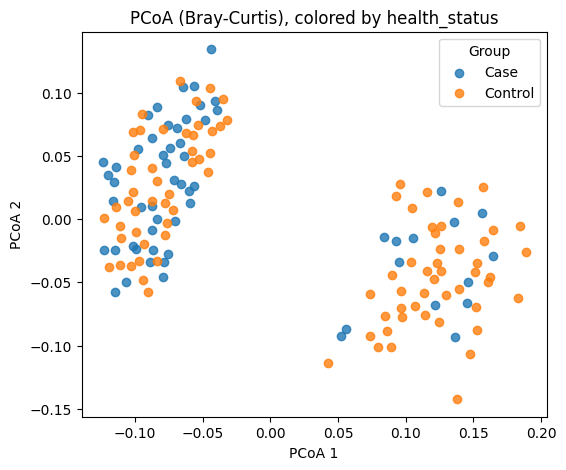

In [84]:
#@title 🔵 CHOOSE — PCoA on Bray-Curtis distance
pcoa_color_by = "health_status" #@param ["health_status", "batch"]

X_for_pcoa = X_raw[selected_features]
color_series = y_raw if pcoa_color_by == "health_status" else batch_raw
_ = plot_pcoa_bray_curtis(X_for_pcoa, color_series, title=f"PCoA (Bray-Curtis), colored by {pcoa_color_by}")

🔴 **DISCUSS — PCoA vs PCA**

Change `pcoa_color_by` above and re-run once for `health_status`, once for `batch`.

1. Does Bray-Curtis PCoA tell a different story than CLR + PCA did in Part 2, or the same one?
2. Bray-Curtis is computed directly on relative abundances (no log-ratio). Does that change what it is sensitive to?

<details>

<summary>💡 Show discussion notes</summary>

PCA on CLR-transformed data and PCoA on Bray-Curtis distances are not asking exactly the same question.

CLR + PCA works on log-ratio transformed abundances. This means that it focuses on relative changes between taxa. In compositional microbiome data, this is important because only relative abundances are observed: an apparent increase in one taxon necessarily affects the relative abundance of the others. CLR tries to represent the data in a geometry that is more appropriate for compositions.

Bray-Curtis PCoA is different. Bray-Curtis is computed directly on relative abundances, without log-ratio transformation. It measures how different two samples are in terms of their taxonomic abundance profiles. It is therefore more sensitive to dominant taxa and to large absolute differences in relative abundance. Rare taxa usually contribute less unless they become abundant enough to affect the distance.

So the two plots can tell related but not identical stories.


The practical lesson is:

- CLR + PCA is useful for visualizing log-ratio structure in compositional data.

- Bray-Curtis PCoA is useful for visualizing ecological dissimilarity based on relative abundances.

- Agreement between the two strengthens the interpretation.

- Disagreement is a warning that the conclusion depends on representation, distance, or preprocessing.

- Neither plot proves that `health_status` is predictable. They are diagnostic plots, not validation results.

In short: Bray-Curtis PCoA may tell the same broad story as CLR + PCA, but it is sensitive to a different notion of sample similarity. If both are dominated by batch rather than health status, the main conclusion is that technical confounding is likely stronger than the biological signal.

</details>

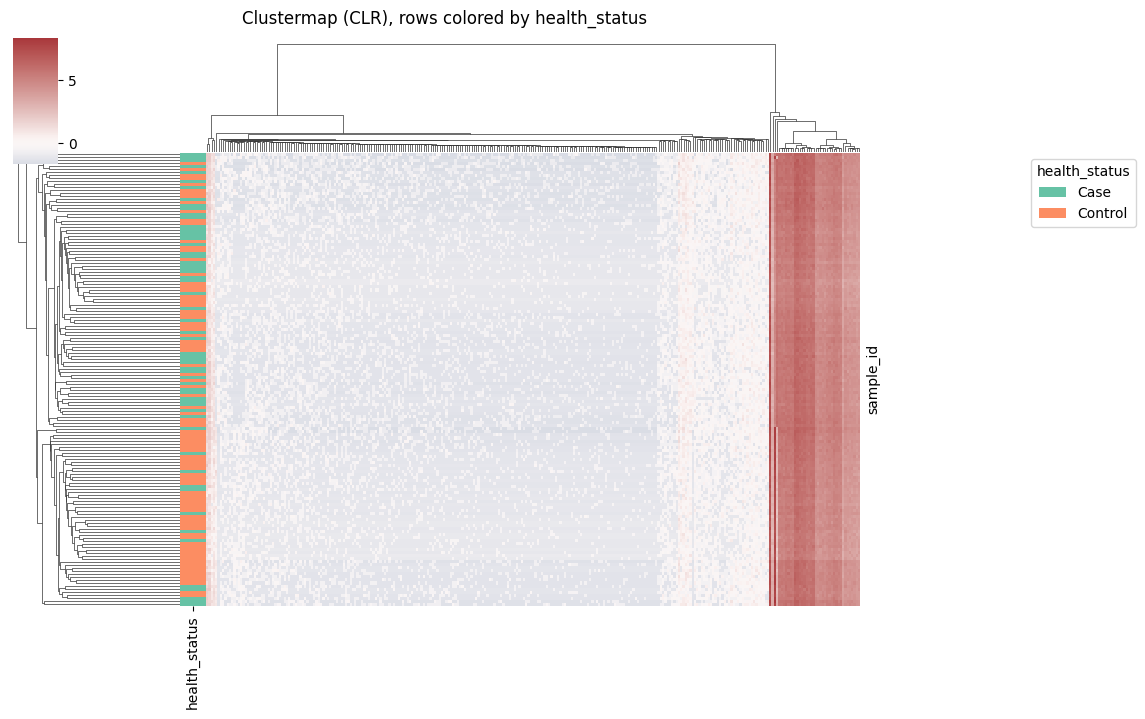

In [85]:
#@title 🔵 CHOOSE — Clustermap
clustermap_color_by = "health_status" #@param ["health_status", "batch"]

color_series = (y_raw if clustermap_color_by == "health_status" else batch_raw).copy()
color_series.name = clustermap_color_by
plot_clustermap(Xt, selected_features, color_series, title=f"Clustermap (CLR), rows colored by {clustermap_color_by}")

🔴 **DISCUSS — What does the clustermap reveal?**

Compare the same CLR clustermap colored first by `batch` and then by `health_status`.

1. Do samples cluster more clearly by `batch` or by `health_status`?
2. What does this suggest about the dominant source of variation in the dataset?
3. Why could this be dangerous for a supervised classifier?
4. What would happen if `batch` and `health_status` were partially confounded?

<details>
<summary>💡 Show discussion notes</summary>

The clustermap suggests that the global structure of the data is more strongly associated with `batch` than with `health_status`.

When rows are colored by `batch`, samples from the same batch tend to appear in contiguous regions of the dendrogram. This means that samples processed in the same batch have more similar CLR abundance profiles than samples from different batches.

When the same clustermap is colored by `health_status`, cases and controls are more mixed. There is no equally clear separation between the two biological groups. This does not prove that there is no disease-associated microbiome signal, but it suggests that the strongest visible source of variation is technical rather than biological.

This is a warning sign for supervised modelling. If `batch` and `health_status` are even partially confounded, a classifier may learn batch-specific taxa instead of disease-associated taxa. In that case, cross-validation performance can look good, but the model may fail on new data generated in a different batch.

The practical conclusion is that batch should not be treated as a minor detail. Before trusting the classifier, we should check:

- whether `health_status` is balanced across batches;
- whether model performance remains stable under grouped cross-validation by batch;
- whether important features are batch-associated;
- whether batch correction or explicit adjustment is needed.

In short: the clustermap does not validate the disease signal. It mainly tells us that batch is a strong candidate confounder.

</details>

🟡 **VOTE — before you run the next cell**

We are about to scan k from 2 to 8 and compute the silhouette score for each value, on the same CLR-transformed data used for the clustermap.

Vote: which k do you expect to come out best?

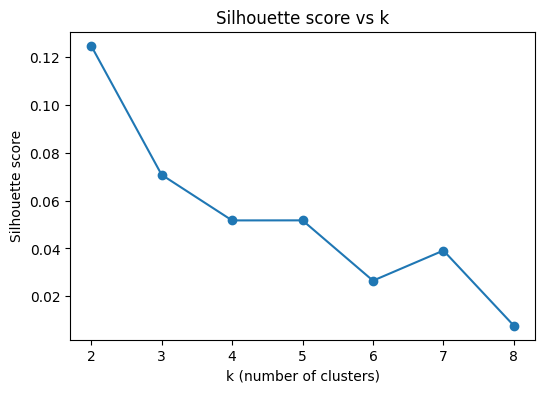

Silhouette scores by k:
  k=2: 0.125  <-- highest
  k=3: 0.071
  k=4: 0.052
  k=5: 0.052
  k=6: 0.027
  k=7: 0.039
  k=8: 0.008

Best k by silhouette score: 2


In [86]:
#@title 🟢 RUN — Silhouette analysis: which k fits the data best?
k_range = range(2, 9)

sil_scores = []
for k_try in k_range:
    km_try = KMeans(n_clusters=k_try, n_init=10, random_state=RANDOM_STATE)
    labels_try = km_try.fit_predict(Xt)
    sil_scores.append(silhouette_score(Xt, labels_try))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(k_range), sil_scores, marker="o")
ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette score vs k")
ax.set_xticks(list(k_range))
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print("Silhouette scores by k:")
for k_try, s in zip(k_range, sil_scores):
    marker = "  <-- highest" if k_try == best_k else ""
    print(f"  k={k_try}: {s:.3f}{marker}")
print(f"\nBest k by silhouette score: {best_k}")

🔴 **DISCUSS — Reading the silhouette curve**

1. Was the best \(k\) the same as the one you expected?

2. The silhouette score is close to 0 for all tested values of \(k\). What does this suggest about how “clusterable” the data really are?

3. This dataset was generated with `N_BATCHES = 3`. Does the silhouette-optimal \(k\) match 3?

4. If not, what does this tell us about the difference between “best clustering” and known experimental metadata?

<details>

<summary>💡 Show discussion notes</summary>

The silhouette-optimal \(k\) does not have to match the number of batches, classes, or any other known grouping.

Silhouette answers a geometric question: are samples closer to points in their own cluster than to points in other clusters? It does not know about `batch`, `health_status`, or the experimental design.

Here, the best value is \(k = 2\), but the silhouette score is low. This means that \(k = 2\) is only the best among the tested options. It does not mean that the data contain two well-separated clusters.

This is important because the dataset was generated with `N_BATCHES = 3`. If silhouette prefers \(k = 2\), it does not mean there are only two batches. It means that, under this representation and clustering method, the strongest geometric split is a two-way split. The three batches may still exist, but they may be overlapping, noisy, or not shaped like compact k-means clusters.

The practical lesson is: “best by silhouette” is not the same as “true number of biological or technical groups.” Silhouette helps diagnose cluster geometry, but it does not replace metadata.

</details>

🟡 **VOTE — before you run the next cell**

We will run k-means on the same CLR-transformed data.

Vote: do you expect the resulting clusters to line up with `health_status`, with `batch`, with neither, or with both?

k = 3 -> silhouette score: 0.071

Cluster vs health_status:


health_status,Case,Control
cluster,,
0,14,46
1,18,14
2,27,31



Cluster vs batch:


batch,batch_1,batch_2,batch_3
cluster,,,
0,60,0,0
1,0,7,25
2,0,20,38


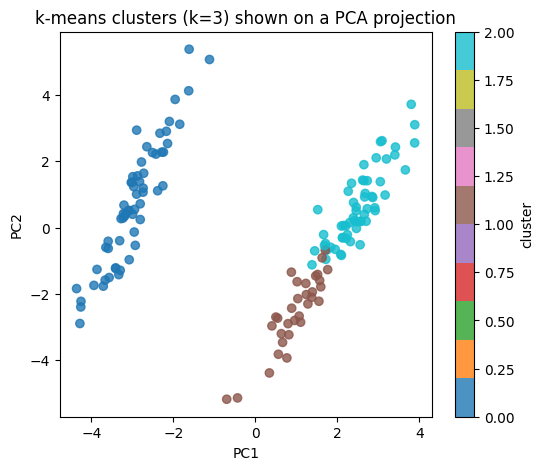

In [87]:
#@title 🔵 CHOOSE — k-means clustering
k = 3 #@param {type:"integer"}

cluster_labels, sil = kmeans_experiment(Xt, k, y_raw, batch_raw)

🔴 **DISCUSS 3 — What did unsupervised learning actually find?**

Across PCA, PCoA, the clustermap, and k-means:

1. Did any of these line up cleanly with `health_status`?
2. Did any of them line up with `batch`?
3. If unsupervised methods mostly reveal batch structure, does that mean there is no biological signal -- or does it mean unsupervised learning is simply not the right tool to find it?

<details>
<summary>💡 Show discussion notes</summary>

In this dataset, structure driven by `batch` is stronger than structure driven by `health_status` -- so PCA/PCoA/clustering will mostly line up with batch, not with biology. That does not mean the biological signal is absent, only that it is not the *dominant* source of variance, which is what unsupervised methods are built to find. A supervised model, trained specifically against the label, can still recover a real (if more modest) signal -- which is exactly what Part 4 tests next.

</details>

Keep this in mind: we are about to test whether a **supervised** model, trained specifically against the `health_status` label, can recover a signal that unsupervised methods did not show you for free.

# Part 4 — First supervised model

We now train a baseline classifier. The objective is not to maximize performance blindly. The objective is to ask whether the result is credible.

In [88]:
#@title 🔵 CHOOSE — Baseline model and validation setup
positive_label = "Case" #@param {type:"string"}
model_name = "random_forest" #@param ["logistic_regression", "random_forest"]
validation = "stratified_cv" #@param ["holdout_split", "stratified_cv"]

y, class_names = encode_target(y_raw, positive_label=positive_label)
print("Class names:", class_names)
print(pd.Series(y).value_counts().rename(index={0: class_names[0], 1: class_names[1]}))

model = make_model(model_name=model_name, representation=representation, min_prevalence=min_prevalence, pseudocount=pseudocount)

if validation == "holdout_split":
    fitted_model, split_data = evaluate_holdout(model, X_raw, y)
else:
    cv_results = evaluate_cv(model, X_raw, y, cv_strategy="stratified_cv")

Class names: ['not Case', 'Case']
not Case    91
Case        59
Name: count, dtype: int64


,metric,mean,std
0,accuracy,0.773,0.057
1,balanced_accuracy,0.722,0.076
2,f1,0.613,0.141
3,roc_auc,0.846,0.100


🔴 **DISCUSS 4 — Which metric should we trust?**

Look at accuracy, balanced accuracy, F1-score, ROC-AUC, and the confusion matrix.

1. Are the classes balanced?

2. Do accuracy and balanced accuracy tell the same story here?

3. Does the confusion matrix reveal asymmetric errors between `Case` and `not Case`?

4. Which error is more problematic for this biological question: missing a true case or falsely labelling a control as a case?

5. Is ROC-AUC enough, on its own, to claim the model is useful?

<details>

<summary>💡 Show discussion notes</summary>

The key point is that each metric answers a different question:

- accuracy: how many predictions are correct overall;

- balanced accuracy: how well the model performs across classes;

- F1-score: how well the model balances precision and recall for the positive class;

- ROC-AUC: how well the model ranks cases above controls across thresholds;

- confusion matrix: what kinds of mistakes the model actually makes.

In this dataset, the metrics are internally consistent and suggest a reasonable predictive signal. But this is not yet enough to trust the model biologically. We still need to check whether the signal is robust, whether it survives proper validation, and whether the model is learning `health_status` rather than batch-related structure.

</details>

# Part 5 — Decision game: which model would you trust?

So far we only looked at one model at a time. Real projects almost always compare a few candidates, under identical conditions, before choosing one.

🟡 **VOTE — before you run the next cell**

We will compare three models with identical preprocessing and identical 5-fold cross-validation: **Logistic Regression**, **Random Forest**, and **SVM (RBF kernel)**.

Vote, before seeing any numbers: which one do you expect to score highest on balanced accuracy? Separately: which one would you trust the most even if it is not the top scorer, and why?

,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std
model,,,,
logistic_regression,0.693,0.057,0.799,0.062
random_forest,0.722,0.076,0.846,0.100
svm_rbf,0.659,0.089,0.750,0.094


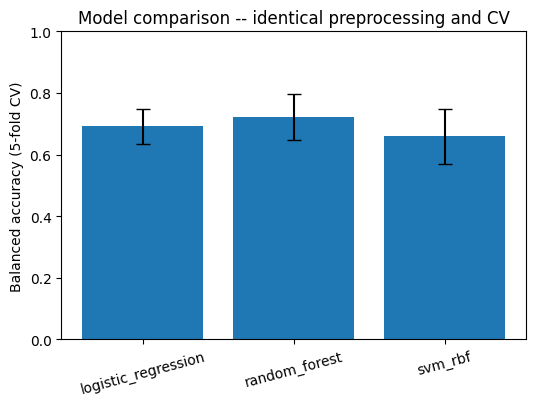

In [89]:
#@title 🟢 RUN — Compare three models (identical CV, no cherry-picking)
def compare_models(X, y, representation, min_prevalence, pseudocount):
    candidates = {
        "logistic_regression": make_model("logistic_regression", representation, min_prevalence, pseudocount),
        "random_forest": make_model("random_forest", representation, min_prevalence, pseudocount),
        "svm_rbf": Pipeline([
            ("preprocess", MicrobiomePreprocessor(representation, min_prevalence, pseudocount)),
            ("scale", StandardScaler()),
            ("model", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE)),
        ]),
    }

    rows = []
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    for name, pipe in candidates.items():
        scores = cross_validate(pipe, X, y, cv=cv,
                                 scoring={"balanced_accuracy": "balanced_accuracy", "roc_auc": "roc_auc"},
                                 n_jobs=-1)
        rows.append({
            "model": name,
            "balanced_accuracy_mean": np.mean(scores["test_balanced_accuracy"]),
            "balanced_accuracy_std": np.std(scores["test_balanced_accuracy"]),
            "roc_auc_mean": np.mean(scores["test_roc_auc"]),
            "roc_auc_std": np.std(scores["test_roc_auc"]),
        })
    result = pd.DataFrame(rows).set_index("model")
    display(result.round(3))

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(result.index, result["balanced_accuracy_mean"], yerr=result["balanced_accuracy_std"], capsize=5)
    ax.set_ylabel("Balanced accuracy (5-fold CV)")
    ax.set_ylim(0, 1)
    ax.set_title("Model comparison -- identical preprocessing and CV")
    plt.xticks(rotation=15)
    plt.show()
    return result

model_comparison = compare_models(X_raw, y, representation, min_prevalence, pseudocount)

🔴 **DISCUSS 5 — Best score is not the only criterion**

Look at the model comparison plot.

1. Which model has the highest mean balanced accuracy?
2. Was it the model you expected?
3. Are the error bars small enough to trust the ranking?
4. If two models perform similarly, would you prefer the more interpretable one?
5. For a biological paper, should model choice depend only on performance?

<details>
<summary>💡 Show discussion notes</summary>

Random Forest has the highest mean balanced accuracy.

However, the best model is not automatically the one with the largest bar. We also need to consider variability across folds, interpretability, and the scientific goal.

If two models perform similarly, Logistic Regression may be preferable because it is simpler and easier to interpret. Random Forest may be preferable when nonlinear effects and interactions matter, but it usually needs post-hoc interpretation tools such as SHAP or permutation importance.

For a biological paper, the strongest choice is usually not “maximum score at any cost”, but a balance between performance, robustness, and interpretability.

In short: Random Forest wins here on balanced accuracy, but model selection should also consider uncertainty and biological interpretability.

</details>

# Part 6 — Decision game: the tempting but wrong pipeline

We now intentionally build a **leaky** pipeline.

The common mistake: perform supervised feature selection on the full dataset before train/test splitting.

This allows information from the test set to influence the selected features. The result can look excellent but fail to generalize.

BAD / LEAKY PIPELINE PERFORMANCE


,score
accuracy,0.895
balanced_accuracy,0.890
f1,0.867
roc_auc,0.962


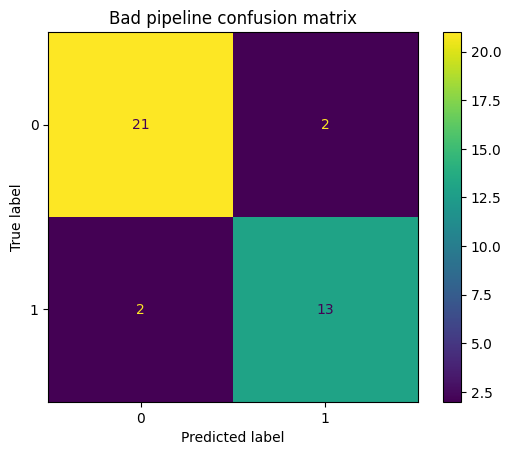

In [90]:
#@title 🟢 RUN — Bad pipeline: supervised feature selection before splitting
k_features = 50 #@param {type:"integer"}

# Transform full dataset first
Xt_full, features_full = get_transformed_matrix(X_raw, representation, min_prevalence, pseudocount)

# WRONG: supervised feature selection on the full dataset
selector = SelectKBest(score_func=f_classif, k=min(k_features, Xt_full.shape[1]))
Xt_selected = selector.fit_transform(Xt_full, y)

X_train, X_test, y_train, y_test = train_test_split(Xt_selected, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

bad_model = LogisticRegression(max_iter=3000, class_weight="balanced", solver="liblinear", random_state=RANDOM_STATE)
bad_model.fit(X_train, y_train)
pred = bad_model.predict(X_test)
score = bad_model.predict_proba(X_test)[:, 1]

bad_metrics = pd.Series({
    "accuracy": accuracy_score(y_test, pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, pred),
    "f1": f1_score(y_test, pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, score),
}).round(3)

print("BAD / LEAKY PIPELINE PERFORMANCE")
display(bad_metrics.to_frame("score"))

ConfusionMatrixDisplay.from_predictions(y_test, pred)
plt.title("Bad pipeline confusion matrix")
plt.show()

🔴 **DISCUSS 6 — Would you report this performance?**

The model looks excellent: high accuracy, high F1, and very high ROC-AUC.

Would you report this result?

A. Yes, because the AUC is high.  
B. No, because supervised feature selection used the full dataset before splitting.  
C. No, because preprocessing, feature selection, and model tuning must be learned only from the training data.  
D. I would compare it with a leakage-free pipeline.

<details>
<summary>💡 Show discussion notes</summary>

Correct answers: **B, C, D**.

This performance should not be reported as a valid estimate of generalization.

The problem is not the classifier itself. The problem is that feature selection was performed before the train/test split, using the full dataset. If the selected features were chosen because they were associated with `health_status`, then the test labels influenced which features entered the model.

That makes the test set no longer independent. The model is being evaluated on samples that already contributed to the feature-selection decision.

The high ROC-AUC is therefore suspicious: it may reflect real signal, but it may also reflect leakage.

The correct workflow is to put feature selection inside the validation loop:

1. split the data;
2. fit feature selection only on the training set;
3. apply the selected features to the test set;
4. train the model on the training set;
5. evaluate on the untouched test set.

In short: high performance is not enough. If the pipeline is leaky, the estimate is biased and should not be reported as evidence that the model generalizes.

</details>

In [91]:
#@title 🟢 RUN — Correct pipeline: preprocessing and model inside cross-validation
correct_model = make_model(model_name=model_name, representation=representation, min_prevalence=min_prevalence, pseudocount=pseudocount)

print("LEAKAGE-FREE CROSS-VALIDATION PERFORMANCE")
correct_cv = evaluate_cv(correct_model, X_raw, y, cv_strategy="stratified_cv")

LEAKAGE-FREE CROSS-VALIDATION PERFORMANCE


,metric,mean,std
0,accuracy,0.773,0.057
1,balanced_accuracy,0.722,0.076
2,f1,0.613,0.141
3,roc_auc,0.846,0.100


🔴 **DISCUSS 7 — Why did performance change?**

If the leaky pipeline performed better than the proper pipeline, what does the difference represent?

<details>
<summary>💡 Show answer</summary>

It is not "lost performance." It is the amount of optimism introduced by leakage.

> The honest result is not the highest result.
> The honest result is the one obtained under a defensible validation design.

</details>

# Part 7 — Is the model secretly learning the batch?

We already saw, in Parts 1 and 3, that `batch` is unevenly distributed across `health_status`, and that unsupervised methods pick up batch structure strongly. Now we test directly whether that leaks into the supervised model's performance.

RANDOM 5-FOLD CV


,metric,mean,std
0,accuracy,0.773,0.057
1,balanced_accuracy,0.722,0.076
2,f1,0.613,0.141
3,roc_auc,0.846,0.100



BATCH-GROUPED CV (each batch held out in turn)


,metric,mean,std
0,accuracy,0.730,0.146
1,balanced_accuracy,0.732,0.118
2,f1,0.561,0.220
3,roc_auc,0.867,0.047


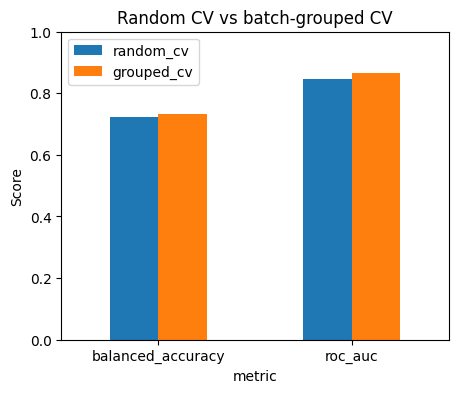

In [92]:
#@title 🟢 RUN — Random CV vs batch-grouped CV
grouped_model = make_model(model_name=model_name, representation=representation, min_prevalence=min_prevalence, pseudocount=pseudocount)

print("RANDOM 5-FOLD CV")
random_cv = evaluate_cv(grouped_model, X_raw, y, cv_strategy="stratified_cv")

print("\nBATCH-GROUPED CV (each batch held out in turn)")
grouped_cv = evaluate_cv(grouped_model, X_raw, y, cv_strategy="grouped_cv", groups=batch_raw.values)

compare_df = pd.DataFrame({
    "random_cv": random_cv.set_index("metric")["mean"],
    "grouped_cv": grouped_cv.set_index("metric")["mean"],
})
fig, ax = plt.subplots(figsize=(5, 4))
compare_df.loc[["balanced_accuracy", "roc_auc"]].plot(kind="bar", ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Random CV vs batch-grouped CV")
plt.xticks(rotation=0)
plt.show()

🔴 **DISCUSS 8 — Random split or grouped split?**

Random CV and batch-grouped CV answer different questions.

Random CV asks: *can the model predict new samples drawn from the same mixture of batches?*  
Grouped CV asks: *can the model generalize to a batch it has never seen before?*

If random CV is higher than batch-grouped CV, what does that suggest?

A. The model may have learned batch-specific signatures, not only biology.  
B. Random CV may have placed very similar same-batch samples in both train and test.  
C. Grouped CV is closer to what happens when the model meets a genuinely new batch.  
D. The model should be trusted because random CV was higher.

Also: does this match what the clustermap, PCA/PCoA, and k-means already hinted at?

<details>
<summary>💡 Show discussion notes</summary>
Correct answers: **A, B, C**.

Random CV performs better because samples from the same batch can appear in both train and test folds. The model may therefore exploit batch-specific structure, not only biology.

Batch-grouped CV is stricter: each test fold is an unseen batch. Here, balanced accuracy drops from about 0.79 to about 0.65, suggesting weaker generalization to new batches.

ROC-AUC remains high, around 0.85, so the model may still rank cases above controls reasonably well. However, the classification threshold is less stable across batches.

This matches the unsupervised analyses: batch is a strong source of structure. Random CV is likely optimistic; grouped CV is the more honest test when batches reflect real technical variation.

</details>

# Part 8 — Interpretation: feature importance and SHAP

Now we interpret the model.

Remember:

> Feature importance explains the model, not necessarily the biology.

A top feature is a candidate for biological interpretation, not proof of causality.

In [93]:
#@title 🟢 RUN — Fit the final model for interpretation
final_pipeline = make_model(model_name=model_name, representation=representation,
                             min_prevalence=min_prevalence, pseudocount=pseudocount)
final_pipeline.fit(X_raw, y)

preprocessor_fitted = final_pipeline.named_steps["preprocess"]
final_clf = final_pipeline.named_steps["model"]
feature_names_final = X_raw.columns[preprocessor_fitted.feature_mask_].to_numpy()
Xt_final = preprocessor_fitted.transform(X_raw)

print("Final model:", model_name)
print("Features used for interpretation:", len(feature_names_final))

Final model: random_forest
Features used for interpretation: 287


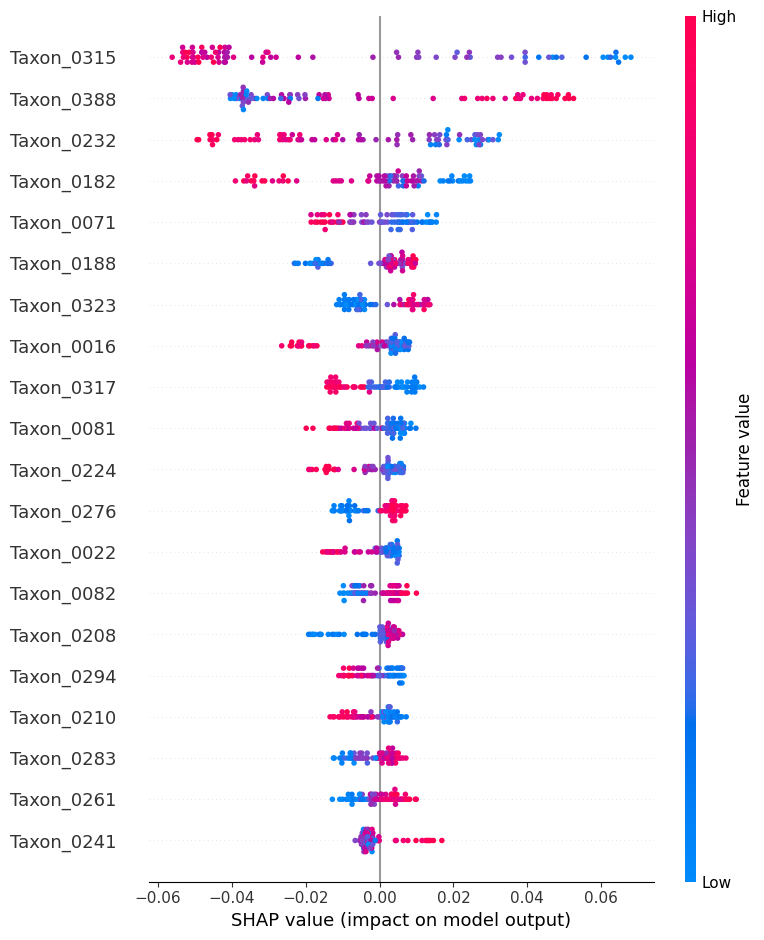


Top 15 features by mean |SHAP value|:


,mean_abs_shap
Taxon_0315,0.041118
Taxon_0388,0.031391
Taxon_0232,0.023503
Taxon_0182,0.013611
Taxon_0071,0.008686
Taxon_0188,0.008069
Taxon_0323,0.007905
Taxon_0016,0.007643
Taxon_0317,0.007405
Taxon_0081,0.005935


In [94]:
#@title 🟢 OPTIONAL — SHAP explanation
run_shap = True #@param {type:"boolean"}
max_shap_samples = 80 #@param {type:"integer"}

if run_shap:
    import shap
    n = min(max_shap_samples, Xt_final.shape[0])
    X_shap = Xt_final[:n]

    if model_name == "random_forest":
        explainer = shap.TreeExplainer(final_clf)
        raw_shap = explainer.shap_values(X_shap)
        if isinstance(raw_shap, list):
            shap_vals = raw_shap[1]
        elif np.asarray(raw_shap).ndim == 3:
            shap_vals = np.asarray(raw_shap)[:, :, 1]
        else:
            shap_vals = raw_shap
    else:
        explainer = shap.LinearExplainer(final_clf, Xt_final)
        shap_vals = explainer.shap_values(X_shap)

    shap.summary_plot(shap_vals, X_shap, feature_names=feature_names_final, max_display=20)

    mean_abs_shap = np.abs(shap_vals).mean(axis=0)
    top_features = pd.Series(mean_abs_shap, index=feature_names_final).sort_values(ascending=False)
    print("\nTop 15 features by mean |SHAP value|:")
    display(top_features.head(15).to_frame("mean_abs_shap"))
else:
    top_features = None
    print("SHAP skipped.")

🔴 **DISCUSS 9 — What can we conclude from top features?**

A. The top feature causes the phenotype.  

B. The top feature was useful for this model, on this dataset.  

C. The top feature is a candidate for biological follow-up.  

D. The top feature should be checked for prevalence, batch association, and stability.  

E. SHAP is proof of mechanism.

<details>

<summary>💡 Show discussion notes</summary>

Correct answers: **B, C, D**.

SHAP tells us which features contributed most to this model’s predictions. It does not prove causality, mechanism, or biological relevance.

A top taxon should be interpreted as a **model-derived candidate**, not as a validated biomarker. It may reflect a real disease-associated signal, but it may also reflect batch effects, sparsity, prevalence differences, or correlations with other taxa.

Before treating a top feature as biologically interesting, we should check whether it is:

- sufficiently prevalent;

- stable across folds or repeated runs;

- not strongly associated with batch;

- consistent with the direction of effect in the SHAP plot;

- plausible in light of prior biological knowledge.

In short: SHAP can generate hypotheses, but it does not validate them. Top features are candidates for follow-up, not proof of mechanism.

</details>

# Part 9 — 🔒 Instructor-only: checking against the ground truth

This dataset is **synthetic**: we know exactly which taxa were built to carry a real `health_status` signal, and which were built to carry only a `batch` artifact.

Requires `instructor_answer_key.csv`.

In [95]:
#@title 🔒 RUN (instructor only) — Compare top features against the ground truth
key_path = "instructor_answer_key.csv" #@param {type:"string"}

if top_features is None:
    print("SHAP was skipped above -- nothing to compare.")
elif not os.path.exists(key_path):
    print(f"'{key_path}' not found -- skip this cell if you are a student.")
else:
    key_df = pd.read_csv(key_path).set_index("taxon")
    top_n = 20
    top_set = set(top_features.head(top_n).index)

    recovered_signal = key_df[(key_df["true_role"] == "health_signal") & (key_df.index.isin(top_set))]
    recovered_batch = key_df[(key_df["true_role"] == "batch_artifact") & (key_df.index.isin(top_set))]

    n_signal_total = (key_df["true_role"] == "health_signal").sum()
    n_batch_total = (key_df["true_role"] == "batch_artifact").sum()

    print(f"Top {top_n} features by mean |SHAP value|:")
    print(f" - True health-signal taxa recovered: {len(recovered_signal)} / {n_signal_total}")
    print(f" - True batch-artifact taxa recovered: {len(recovered_batch)} / {n_batch_total}")
    print(f" - Remaining top features not in the ground-truth list: {top_n - len(recovered_signal) - len(recovered_batch)}")

    print("\nRecovered true health-signal taxa:")
    display(recovered_signal)
    print("\nRecovered batch-artifact taxa (false leads the model also picked up):")
    display(recovered_batch)

'instructor_answer_key.csv' not found -- skip this cell if you are a student.


🔴 **FINAL DISCUSS — What did the model really learn?**

In this synthetic dataset we know the ground truth.

Among the top 20 SHAP features:

- 7 were true health-signal taxa;
- 7 were batch-artifact taxa;
- 6 were other taxa.

So the model learned both biology and batch.

<details>
<summary>💡 Show discussion notes</summary>

This is the key lesson: SHAP tells us what the model used, not whether that signal is biologically correct.

Here, some top SHAP features are true disease-related taxa, but several are batch artifacts. This matches what we already saw: batch structure appeared in the unsupervised analyses, and performance dropped under batch-grouped validation.

In a real study, we do not have a ground-truth table. Therefore, we need indirect checks: grouped validation, batch-association tests, stability across folds, sensitivity to preprocessing, and external validation when possible.

The final message is: explainability is useful, but it is not validation.

</details>

# Part 10 — Final audit

Complete the audit verbally or in small groups.

## Final model audit checklist

1. What is the biological question?
2. What is the phenotype label, and is it reliable?
3. How many samples and features do we have?
4. Are the classes balanced?
5. How sparse is the feature table?
6. Which representation did we use?
7. Did unsupervised exploration (PCA/PCoA/clustering) suggest batch structure, biological structure, or both?
8. Was preprocessing performed inside the validation loop?
9. Which validation strategy was used?
10. Did model comparison (Part 5) change which model you would report?
11. Did batch-grouped validation (Part 7) change your trust in the model?
12. Are the top features stable and biologically plausible?
13. Would you trust this model? Why or why not?

Final answer format:

> We trust / partially trust / do not trust this model because...